# Sim Explores - different model settings

- what are the different settings you can initialize the model with, how do they affect fitting

### Imports

In [1]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam import SpectralModel #This allows us to initialise and fit spectral models
from specparam.plts import plot_spectra # Plot one or multiple power spectra

from matplotlib import pyplot

### Data Simulation Settings

In [2]:
# Simulation settings
n_seconds = 6 # Number of seconds
s_rate = 750 # Sampling rate

times = create_times(n_seconds, s_rate)
n_points = len(times)

# Simulate time series signals
white_signal = np.random.normal(0, 1, n_points)
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

# Compute power spectra
w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)
p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)
b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

### Differing spectral model initialisation settings

#### Aperiodic mode


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters - White Noise: 
 [-4.43568186e+00 -9.94094276e-01  4.35880930e-03] 

Aperiodic parameters - Pink Noise: 
 [-1.52798562 -1.08756324  0.70876255] 

Aperiodic parameters - Brown Noise: 
 [-0.73164915  1.83154

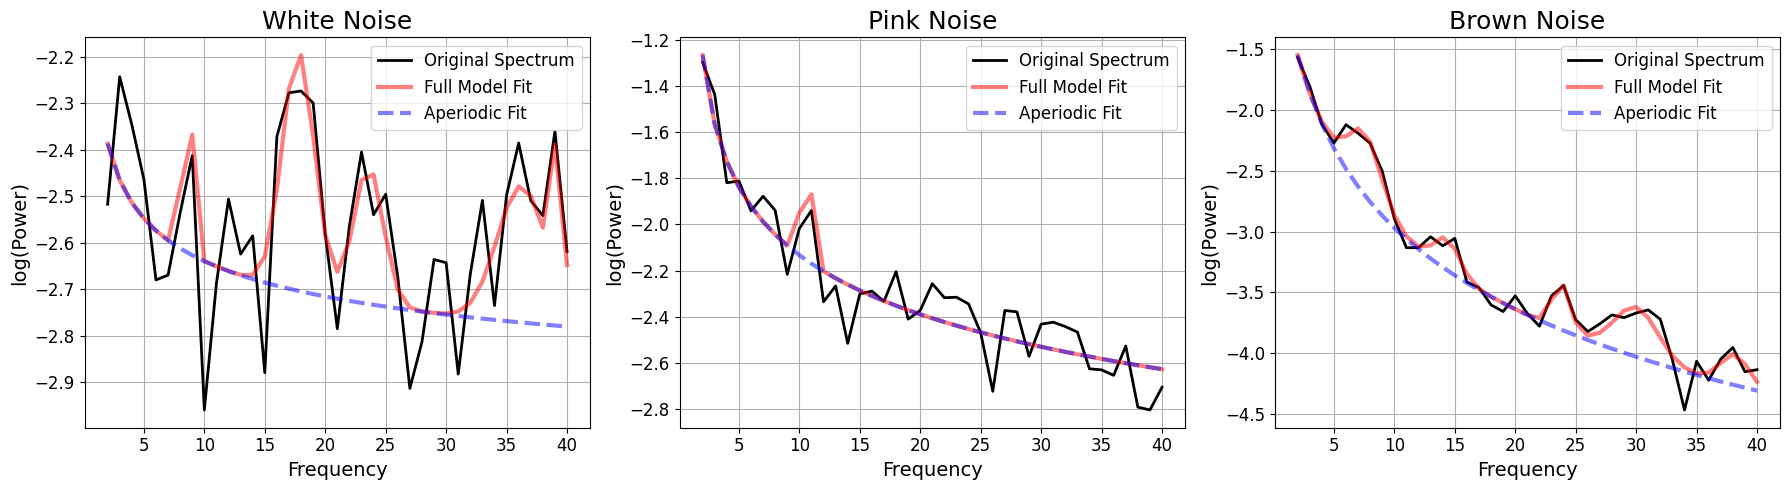

In [3]:
# Aperiodic mode = 'knee'

# Initialise and fit Spectral Modelto the power spectra
fm_w = SpectralModel(aperiodic_mode='knee')
fm_p = SpectralModel(aperiodic_mode='knee')
fm_b = SpectralModel(aperiodic_mode='knee')

# Set frequency range
freq_range = [2, 40]

# Setrtings for plotting figures horizontally
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

# Fitting and plotting models
fm_w.fit(w_freqs, w_powers, freq_range)
fm_w.plot(title = "White Noise", ax=ax1)

fm_p.fit(p_freqs, p_powers, freq_range)
fm_p.plot(title = "Pink Noise", ax=ax2)

fm_b.fit(b_freqs, b_powers, freq_range)
fm_b.plot(title = "Brown Noise", ax=ax3)

# Displaying aperiodic offset and exponent for each signal
print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')

#### Periodic mode


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters - White Noise: 
 [-2.36221624  0.26655118] 

Aperiodic parameters - Pink Noise: 
 [-1.28074067  0.84620095] 

Aperiodic parameters - Brown Noise: 
 [-0.83500589  2.15837558] 



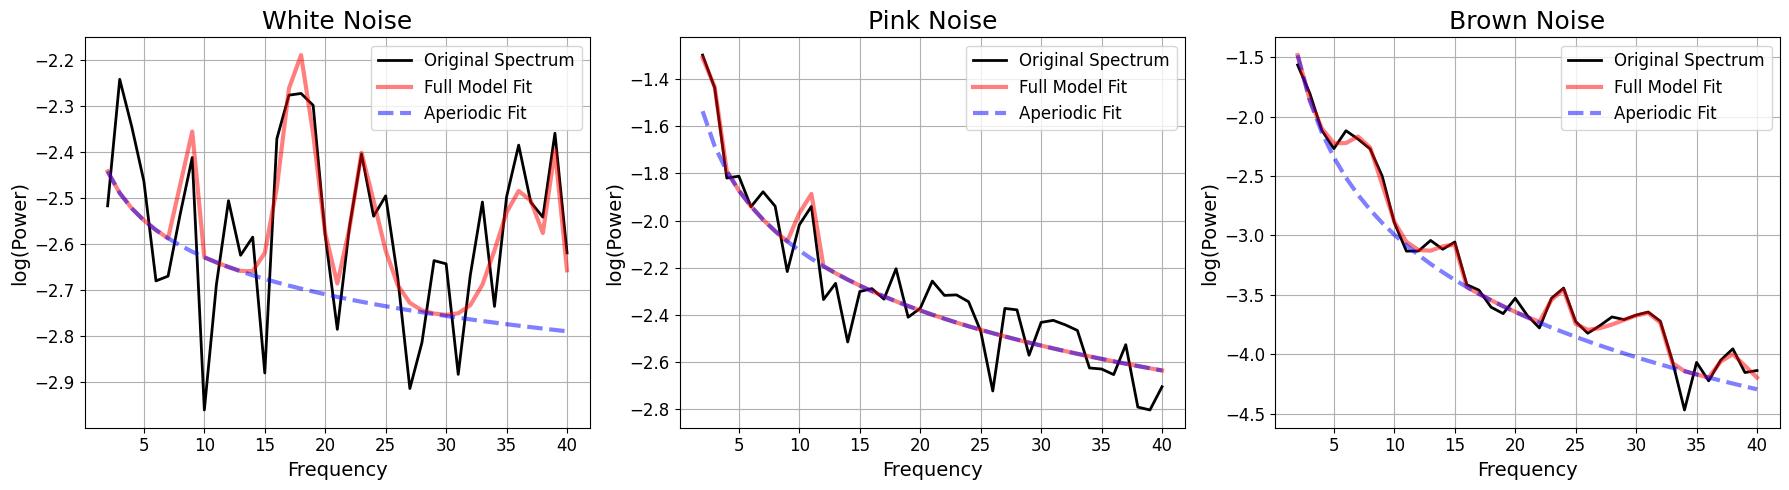

In [4]:
# Periodic mode = 'skewed_gaussian'

# Initialise and fit Spectral Modelto the power spectra
fm_w = SpectralModel(periodic_mode='skewed_gaussian')
fm_p = SpectralModel(periodic_mode='skewed_gaussian')
fm_b = SpectralModel(periodic_mode='skewed_gaussian')

# Set frequency range
freq_range = [2, 40]

# Settings for plotting figures horizontally
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

# Fitting and plotting models
fm_w.fit(w_freqs, w_powers, freq_range)
fm_w.plot(title = "White Noise", ax=ax1)

fm_p.fit(p_freqs, p_powers, freq_range)
fm_p.plot(title = "Pink Noise", ax=ax2)

fm_b.fit(b_freqs, b_powers, freq_range)
fm_b.plot(title = "Brown Noise", ax=ax3)

# Displaying aperiodic offset and exponent for each signal
print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters - White Noise: 
 [-2.35907065  0.260916  ] 

Aperiodic parameters - Pink Noise: 
 [-1.30539361  0.8300555 ] 

Aperiodic parameters - Brown Noise: 
 [-0.8641362   2.13606114] 



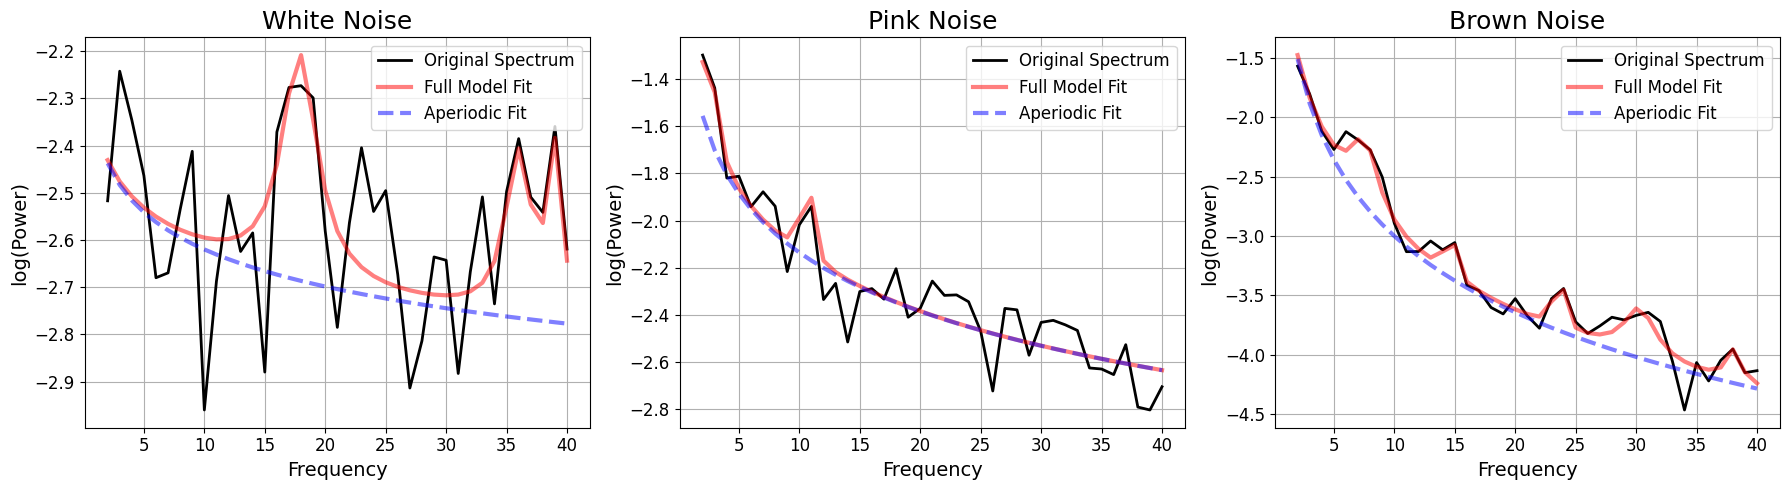

In [5]:
# Periodic mode = 'cauchy'

# Initialise and fit Spectral Modelto the power spectra
fm_w = SpectralModel(periodic_mode='cauchy')
fm_p = SpectralModel(periodic_mode='cauchy')
fm_b = SpectralModel(periodic_mode='cauchy')

# Set frequency range
freq_range = [2, 40]

# Settings for plotting figures horizontally
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

# Fitting and plotting models
fm_w.fit(w_freqs, w_powers, freq_range)
fm_w.plot(title = "White Noise", ax=ax1)

fm_p.fit(p_freqs, p_powers, freq_range)
fm_p.plot(title = "Pink Noise", ax=ax2)

fm_b.fit(b_freqs, b_powers, freq_range)
fm_b.plot(title = "Brown Noise", ax=ax3)

# Displaying aperiodic offset and exponent for each signal
print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')

#### Max peaks


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximatel

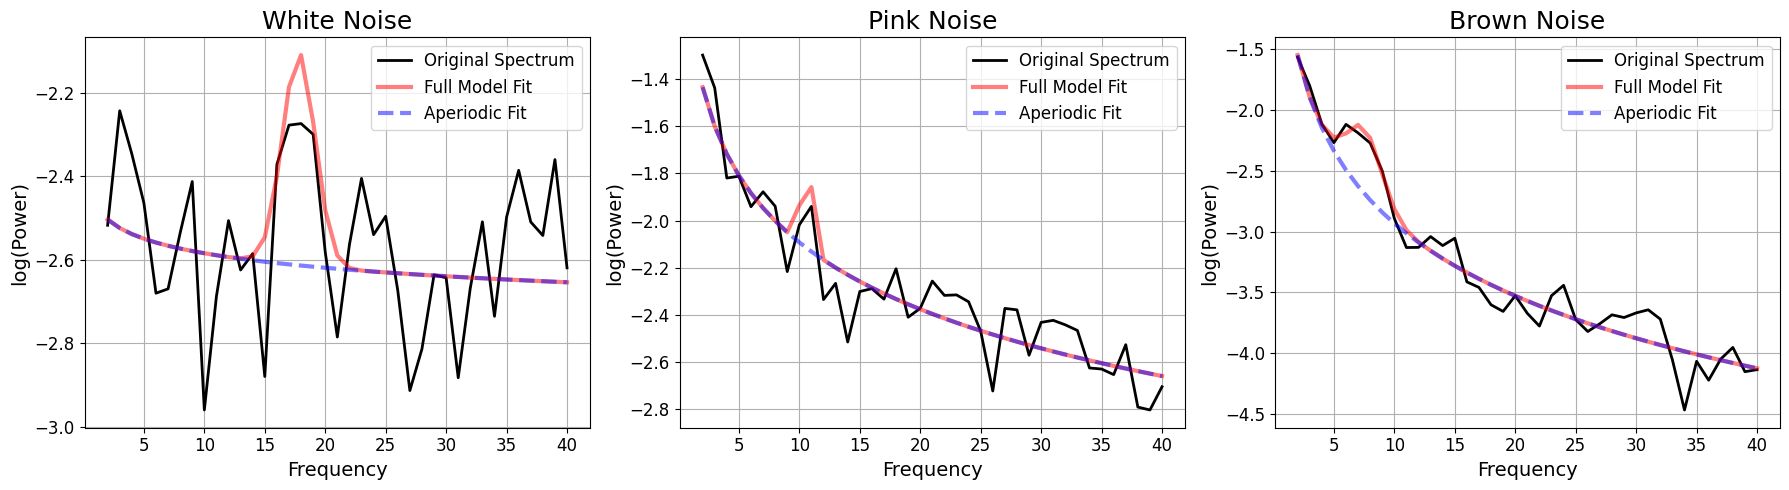

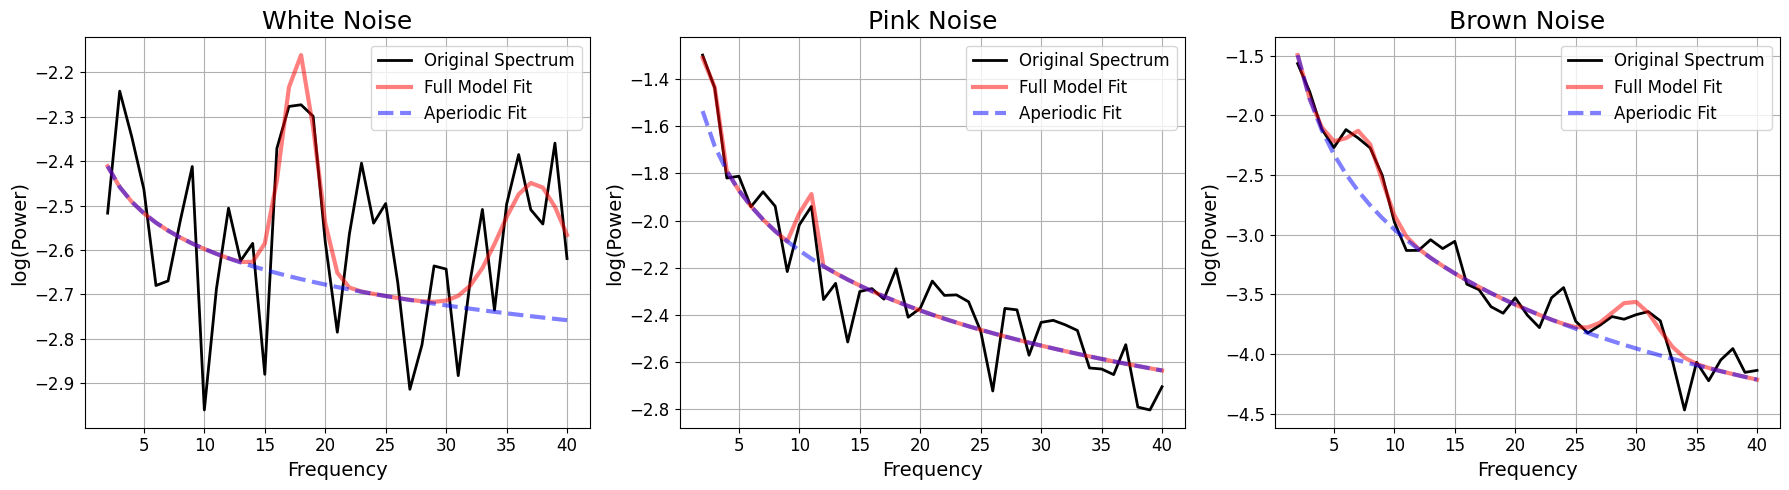

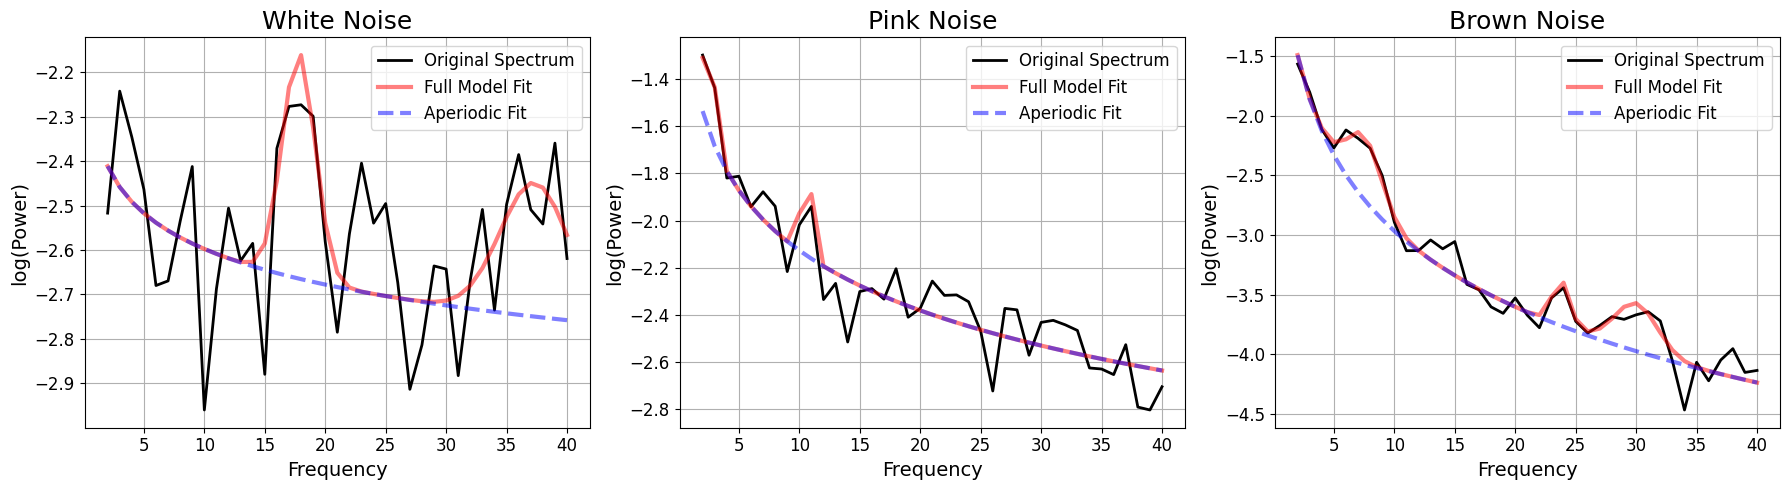

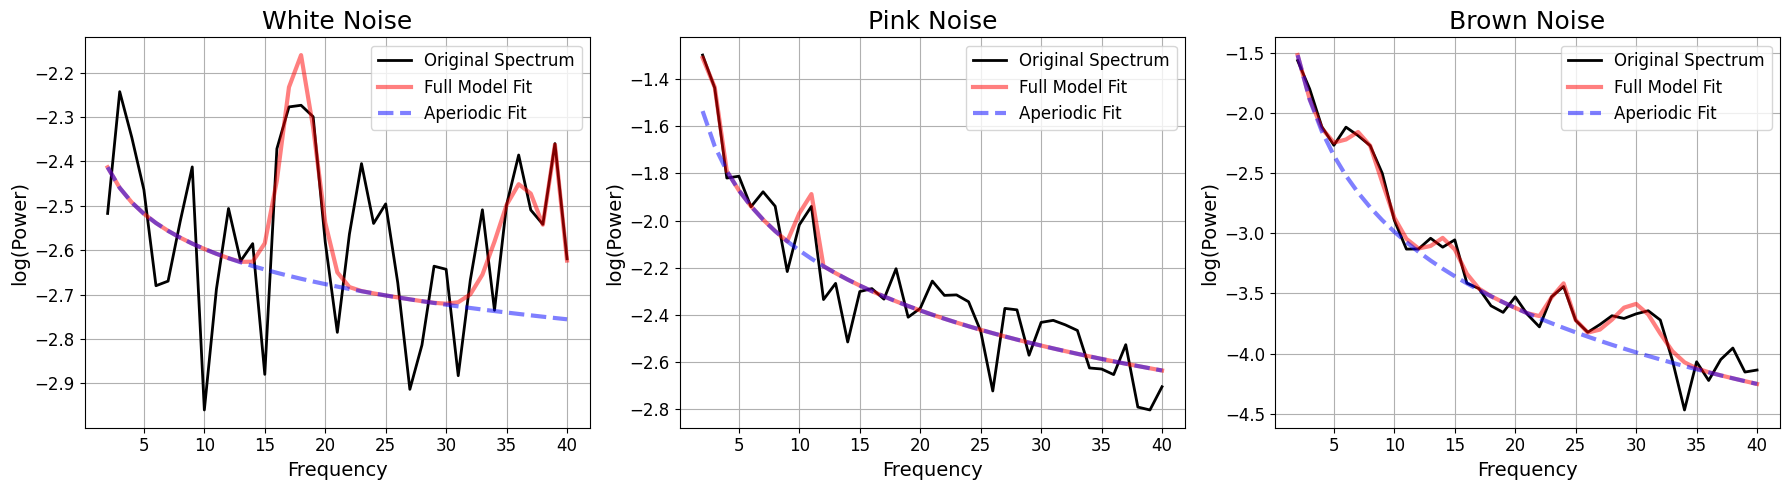

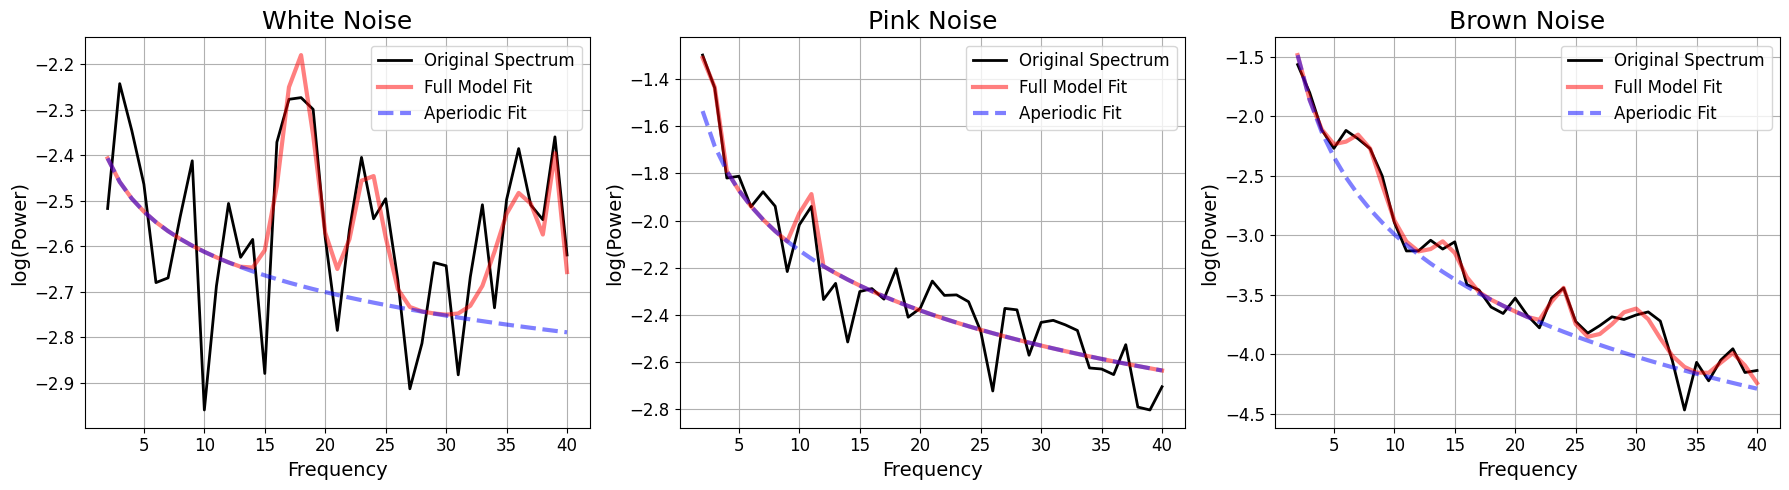

In [7]:
# Max peaks

# Loop which increasing the max number of peaks that are able to be fitted in the model from 1 - 5
# Initialise and fit Spectral Modelto the power spectra
for max_n_peaks in range (1, 6, 1):
    fm_w = SpectralModel(max_n_peaks=max_n_peaks)
    fm_p = SpectralModel(max_n_peaks=max_n_peaks)
    fm_b = SpectralModel(max_n_peaks=max_n_peaks)
    
    # Set frequency range 
    freq_range = [2, 40]

    # Settings for plotting figures horizontally
    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    # Fitting and plotting models
    fm_w.fit(w_freqs, w_powers, freq_range)
    fm_w.plot(title = "White Noise", ax=ax1)

    fm_p.fit(p_freqs, p_powers, freq_range)
    fm_p.plot(title = "Pink Noise", ax=ax2)

    fm_b.fit(b_freqs, b_powers, freq_range)
    fm_b.plot(title = "Brown Noise", ax=ax3)

#### Peak threshold


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximatel

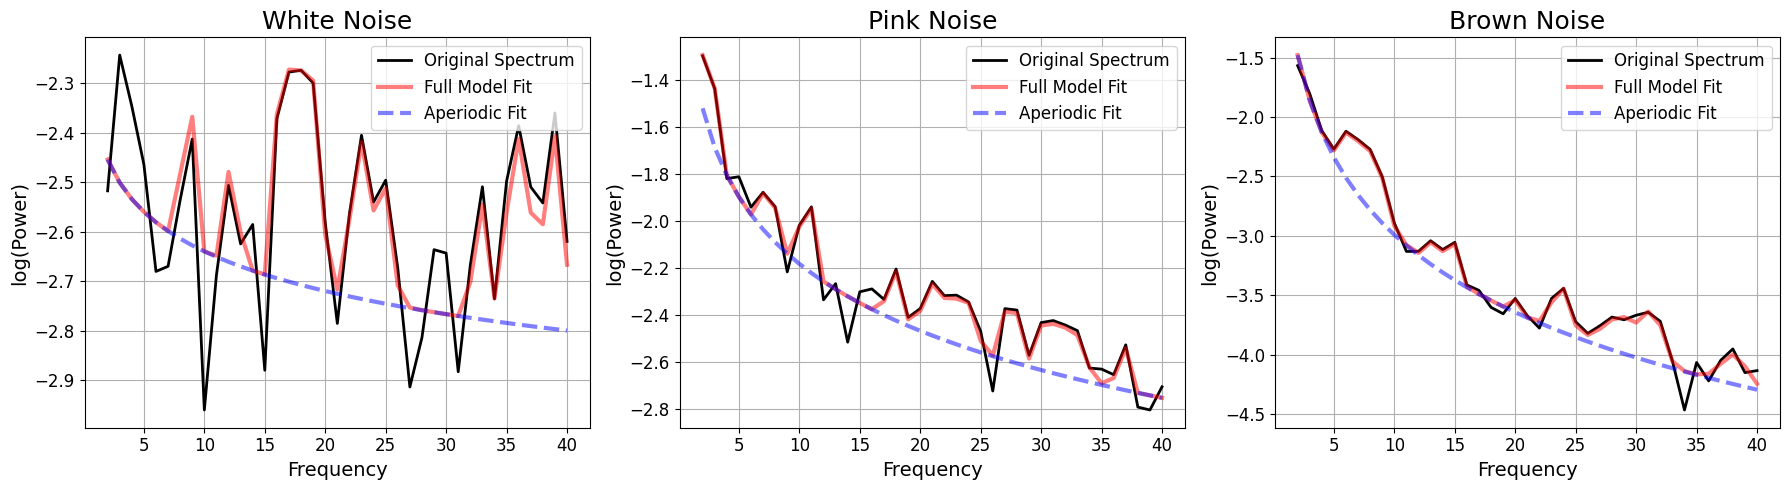

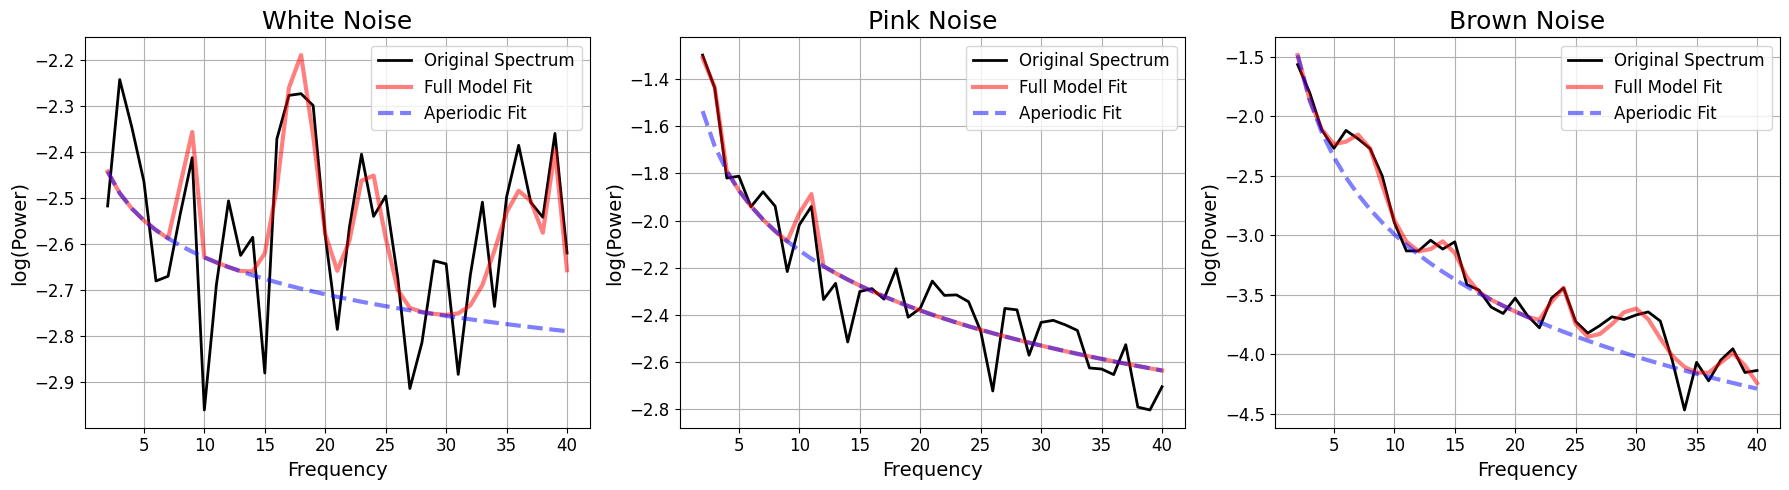

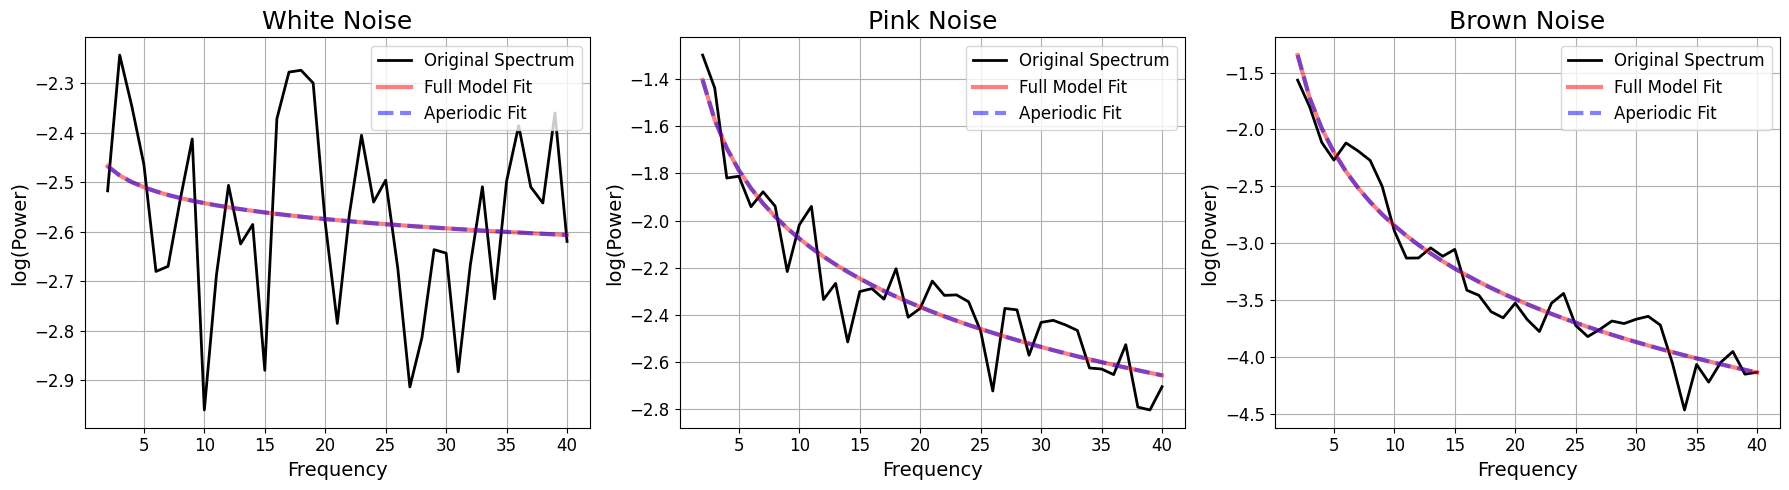

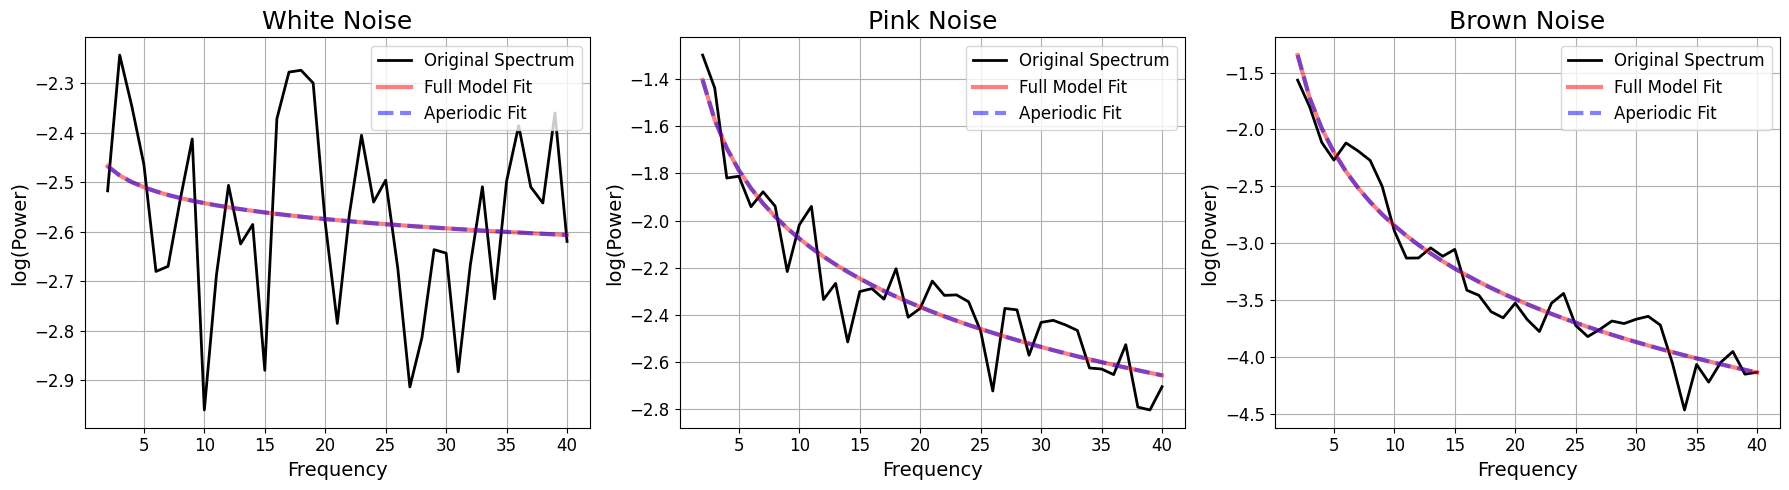

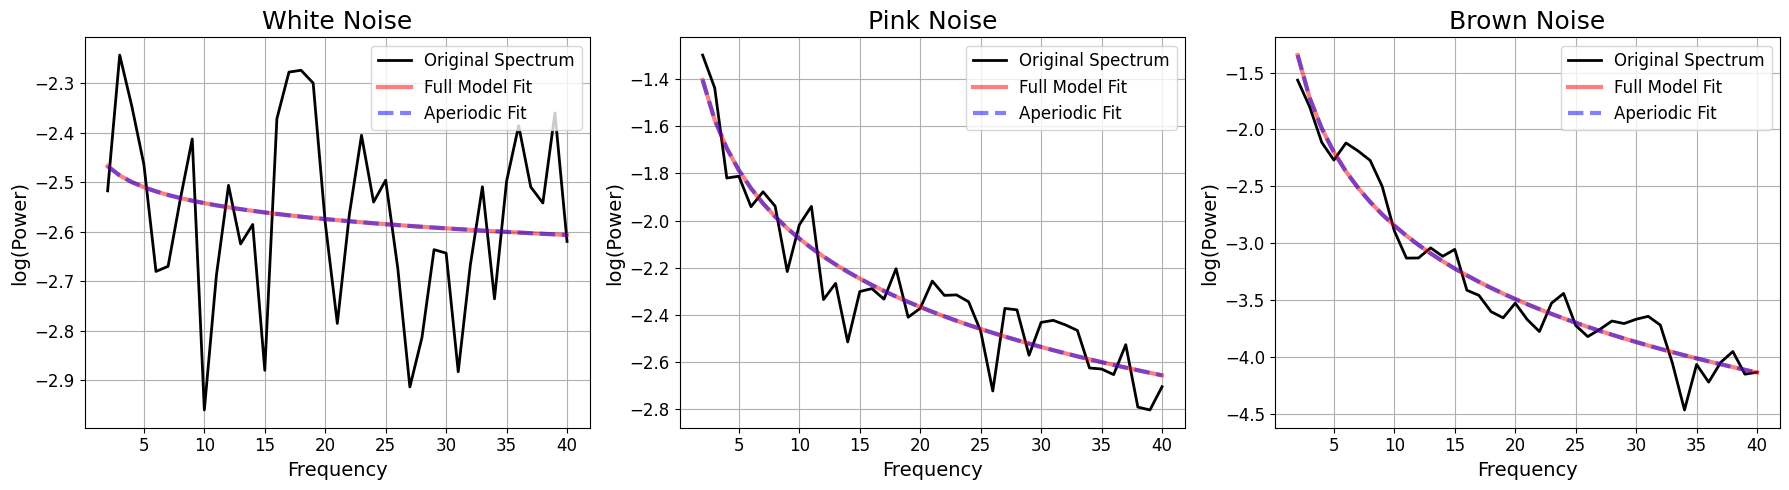

In [8]:
# Peak threshold

# Loop which increasing the peak threshold in the model from 1 - 5
# Initialise and fit Spectral Modelto the power spectra
for peak_threshold in range (1, 6, 1):
    fm_w = SpectralModel(peak_threshold=peak_threshold)
    fm_p = SpectralModel(peak_threshold=peak_threshold)
    fm_b = SpectralModel(peak_threshold=peak_threshold)

    # Set frequency range 
    freq_range = [2, 40]

    # Settings for plotting figures horizontally
    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    # Fitting and plotting models
    fm_w.fit(w_freqs, w_powers, freq_range)
    fm_w.plot(title = "White Noise", ax=ax1)

    fm_p.fit(p_freqs, p_powers, freq_range)
    fm_p.plot(title = "Pink Noise", ax=ax2)

    fm_b.fit(b_freqs, b_powers, freq_range)
    fm_b.plot(title = "Brown Noise", ax=ax3)